# Coursework 2 Part 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Classification with a Convolutional Neural Network <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
- [Task 2](#task-2): Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.nn import Sequential, CrossEntropyLoss, Conv1d, MaxPool1d, Dropout, Flatten, Linear, ReLU
from torch.utils.data import TensorDataset, DataLoader

In [37]:
def normalise(X):
    return (X - np.min(X)) / (np.max(X) - np.min(X))

def basic_graph(x, ys, labels, *, xlog=False, ylog=False, symlog=False, xlabel=None, ylabel=None, alpha=1):
    plt.figure(figsize=(12,8))
    for i, y in enumerate(ys.T):
        plt.plot(x, y, markersize=10, label=labels[i], alpha=alpha)
    plt.xlabel("x")
    plt.ylabel("y")
    if xlog:
        plt.xscale("log")
    if ylog:
        plt.yscale("log")
    if symlog:
        plt.yscale("symlog", linthresh=0.1)
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    plt.legend()
    plt.show()

In [3]:
df = pd.read_csv("neural_activity.csv")
x = df.to_numpy()[:, :-3].astype(float)
y = df.to_numpy()[:, -1].astype(str)
subst_dict = {"R": 0, "L": 1, "F": 2, "B": 3}

N_regions = 40
N_trials = 80

x_norm = normalise(x)

In [4]:
x_r = x_norm.reshape(N_regions, N_trials, -1).transpose(1, 0, 2)
y_r = y.reshape(N_regions, N_trials).T
test_idx = [56, 30, 42, 63, 7, 66, 2, 77, 78, 13, 39, 61, 5, 67, 70, 46]
train_idx = [i for i in range(N_trials) if i not in test_idx]
x_test = x_r[test_idx, :, :]
x_train = x_r[train_idx, :, :]

y_test = y_r[test_idx, 0]
y_train = y_r[train_idx, 0]

y_test = np.array([subst_dict[y] for y in y_test])
y_train = np.array([subst_dict[y] for y in y_train])

N_trials_tr = len(train_idx)
N_trials_te = len(test_idx)

<a name="task-1"></a>

# Task 1: Classification with a Convolutional Neural Network [(index)](#index-task-1)

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [5]:
def get_model(x_train, n_filters, k, pool_size, stride_pool, dropout, classes):
    """
    CNN model in PyTorch:
    - Layers are Conv1d(+ReLU), MaxPool1d, Flatten and Linear(+Softmax).
    - It features an Adam optimiser and CrossEntropyLoss criterion.

    Parameters:
        x_train (np.ndarray): Training data
        n_filters (int): Number of filters to be used in the convolutional layer
        k (int): Kernel size in the convolutional layer
        pool_size (int): MaxPool1d window size
        stride_pool (int): Stride of the MaxPool1d sliding window
        classes (List): Output classes

    Returns:
        Model, criterion and optimiser.

    """

    l_out_conv = x_train.shape[2] - k + 1  # Length after Conv1d (note that the stride is 1)
    l_out_pool = (l_out_conv - pool_size) // stride_pool + 1  # Length after MaxPool1d
    l_in_linear = n_filters * l_out_pool  # Size before Linear layer

    model = Sequential(
        Conv1d(x_train.shape[1], n_filters, kernel_size=k),
        ReLU(),
        MaxPool1d(kernel_size=pool_size, stride=stride_pool),
        Dropout(p=dropout),
        Flatten(),
        Linear(l_in_linear, len(classes)),
    )

    criterion = CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters())

    return model, criterion, optimiser

In [6]:
torch.manual_seed(10)

n_filters = 8
k = 16
pool_size = 16
stride_pool = 4
dropout = 0.8
classes = ["R", "L", "F", "B"]

model, criterion, optimiser = get_model(x_train, n_filters, k, pool_size, stride_pool, dropout, classes)

In [7]:
xtr_tensor = torch.tensor(x_train, dtype=torch.float32)
xte_tensor = torch.tensor(x_test, dtype=torch.float32)
ytr_tensor = torch.tensor(y_train)
yte_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(xtr_tensor, ytr_tensor.squeeze())
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataset = TensorDataset(xte_tensor, yte_tensor.squeeze())
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [8]:
class EarlyStopping:
    """
    EarlyStopping class.

    Attributes:
        max_patience (int): Amount of epochs with no improvement after which training is stopped.
        patience (int): Stores the number of epochs with no improvement.
        best_valid_loss (float): Stores the current value of the best (minimum) validation loss.
        early_stop (bool) True if training needs to be stopped due to the early stopping condition being met.

    Methods:
        step(val_loss, model):  ## New model argument
            Checks current state after an epoch and updates best_loss, patience and early_stop accordingly.
    """

    def __init__(self, max_patience=5):
        self.max_patience = max_patience
        self.patience = 0
        self.best_valid_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None  ## New

    def step(self, val_loss, model):  ## New model argument
        if val_loss < self.best_valid_loss:
            self.best_valid_loss = val_loss
            self.patience = 0
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()} ## New
        else:
            self.patience += 1
            if self.patience >= self.max_patience:
                self.early_stop = True

    def load_best_weights(self, model):
        ## New
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            print("Loaded best model weights!")

In [9]:
def training_loop(train_loader, val_loader, max_num_epochs=200, max_patience=5):
    """
    Training loop with early stopping to monitor the validation accuracy.

    Parameters:
        train_loader (torch.utils.data.DataLoader): Training DataLoader
        val_loader (torch.utils.data.DataLoader): Validation DataLoader
        max_num_epochs (int): Maximum number of epochs
        max_patience (int): max_patience attribute of the EarlyStopping class

    Returns:
        Model, criterion and optimiser.

    """

    history = {'training_loss': [], 'validation_loss': [], 'training_accuracy': [], 'validation_accuracy': []}
    early_stopping = EarlyStopping(max_patience=max_patience)
    best_epoch = 0  # New

    for epoch in range(max_num_epochs):

        tr_loss = 0.0
        tr_correct = 0
        val_loss = 0.0
        val_correct = 0

        # Training
        model.train()
        for inputs, labels in train_loader:
            optimiser.zero_grad() # Setting gradients to zero
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            tr_loss += loss.item()
            tr_correct += (outputs.argmax(dim=1) == labels).sum().item()
            loss.backward() # Computes gradients of the loss
            optimiser.step() # Optimisation step (parameters are updated)

        history['training_loss'].append(tr_loss/len(train_loader))
        history['training_accuracy'].append(100*tr_correct/len(train_dataset))

        # Validation
        model.eval()
        with torch.no_grad():
            for inputs_v, labels_v in val_loader:
                outputs_v = model(inputs_v)
                loss_v = criterion(outputs_v, labels_v)
                val_loss += loss_v.item()
                if labels_v.size(0):
                    val_correct += (outputs_v.argmax(dim=1) == labels_v).sum().item()

        history['validation_loss'].append(val_loss/len(val_loader))
        history['validation_accuracy'].append(100*val_correct/len(test_dataset))

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1}/{max_num_epochs}, Training loss: {tr_loss/len(train_loader)}, Training accuracy: {100*tr_correct/len(train_dataset)}%, Validation loss: {val_loss/len(val_loader)}, Validation accuracy: {100*val_correct/len(test_dataset)}%')

        # Check for early stopping
        early_stopping.step(val_loss / len(val_loader), model) ## New model argument

        if val_loss / len(val_loader) == early_stopping.best_valid_loss:
            # Record the epoch number of the best model
            best_epoch = epoch + 1

        if early_stopping.early_stop:
            print('Early stopping acting.')
            break

    early_stopping.load_best_weights(model)
    print(f"Best model was from Epoch {best_epoch}")

    return history, best_epoch

In [10]:
# Calling the training loop
max_num_epochs = 100
max_patience = 8

# Get the optimal number of epochs using early stopping on the validation set
history, best_num_epochs = training_loop(train_loader, test_loader, max_num_epochs, max_patience)

Epoch 70/100, Training loss: 0.10034347139298916, Training accuracy: 96.875%, Validation loss: 0.14468832314014435, Validation accuracy: 93.75%
Epoch 80/100, Training loss: 0.0762434946373105, Training accuracy: 98.4375%, Validation loss: 0.11085257679224014, Validation accuracy: 93.75%
Epoch 90/100, Training loss: 0.05046670325100422, Training accuracy: 100.0%, Validation loss: 0.11039895564317703, Validation accuracy: 93.75%
Early stopping acting.
Loaded best model weights!
Best model was from Epoch 82


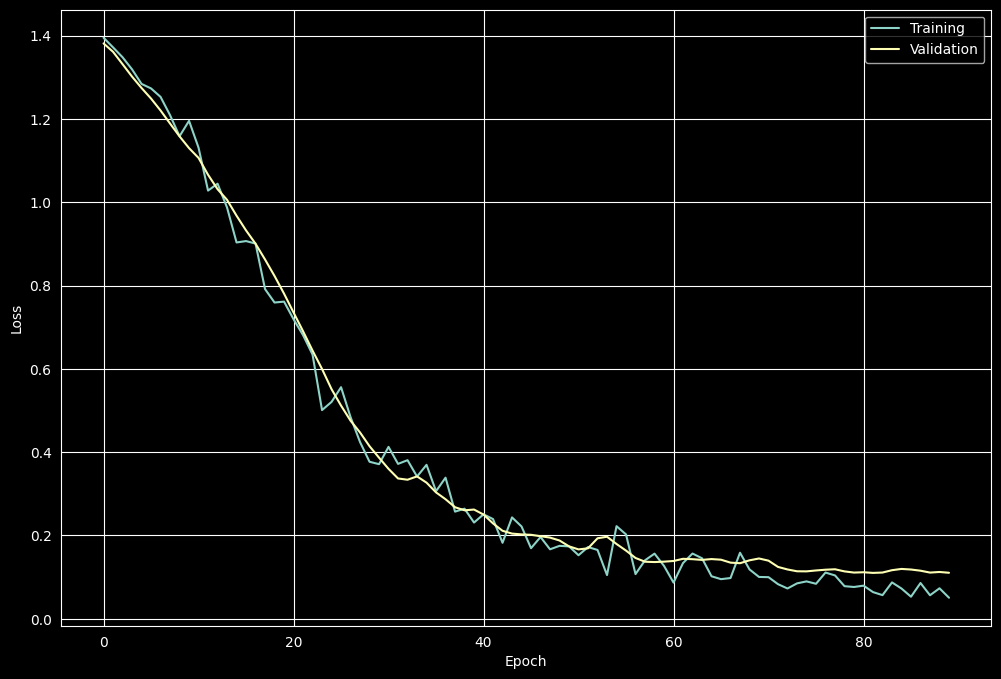

In [12]:
loss = np.vstack([history['training_loss'], history['validation_loss']]).T
basic_graph(range(loss.shape[0]), loss, labels=["Training", "Validation"], xlabel="Epoch", ylabel="Loss")

In [13]:
def pred_accuracy(pred, true):
    return sum(true == pred) / true.shape[0]

In [14]:
pred_train = torch.argmax(model(xtr_tensor), dim=1).detach().numpy()
pred_test = torch.argmax(model(xte_tensor), dim=1).detach().numpy()

print(f"Train set accuracy: {pred_accuracy(pred_train, y_train)}")
print(f"Test set accuracy: {pred_accuracy(pred_test, y_test)}")

Train set accuracy: 1.0
Test set accuracy: 0.9375


From the graph, we can see that our loss function does indeed converge -- our early stopping algorithm stopped at epoch 82, as any further training would yield overfitting. We can also see that the training and validation losses are very similar up until around epoch $70$, where the training loss continues to decrease whereas the validation loss does not. This difference between the training loss and validation loss indicates a slight amount of overfitting.

Testing the accuracy of our predictions using the argmax of the predicted labels yields the same picture -- the training set is predicted with $100\%$ accuracy, whereas the testing set is predicted with only around $94\%$ accuracy. While this is a very good accuracy, indicating that our model has succeeded in predicting the type of trial, it does indicate some level of overfitting to our training set -- ideally, we'd want the testing and training accuracy to be similar.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [36]:
model.train()
preds = np.zeros((10, N_trials_te, len(classes)))
for inputs_te, _ in test_loader:
    for j in range(10):
        pred = torch.softmax(model(inputs_te), 1).detach().numpy()
        preds[j, :, :] = pred

[[[1.56564415e-02 6.14104653e-03 3.16585501e-05 9.78170812e-01]
  [8.62537801e-01 1.63698605e-05 1.24217428e-01 1.32283857e-02]
  [4.88205551e-05 9.92276132e-01 5.87685267e-03 1.79825572e-03]
  [9.57580924e-01 3.18865168e-05 4.14434262e-03 3.82428989e-02]
  [9.99931455e-01 6.11731911e-13 3.20849940e-05 3.64856860e-05]
  [1.15395326e-03 3.57305398e-05 1.71988609e-06 9.98808622e-01]
  [1.47944661e-02 8.51572275e-01 1.31969824e-01 1.66341907e-03]
  [2.35008836e-01 6.65667057e-02 6.88450277e-01 9.97429062e-03]
  [3.15560728e-01 3.22442801e-08 4.04474036e-08 6.84439123e-01]
  [9.99062598e-01 2.05280003e-07 9.67802043e-05 8.40306689e-04]
  [1.70634799e-02 9.93497856e-03 9.72840965e-01 1.60599739e-04]
  [9.69021201e-01 3.03822560e-07 3.08651254e-02 1.13312512e-04]
  [6.74937153e-03 6.82561658e-04 5.28025510e-07 9.92567539e-01]
  [9.54897225e-01 2.02155934e-06 4.13820148e-03 4.09625545e-02]
  [2.80162021e-05 9.89959419e-01 2.94245849e-03 7.07024615e-03]
  [2.77740210e-01 2.25020549e-03 7.18145

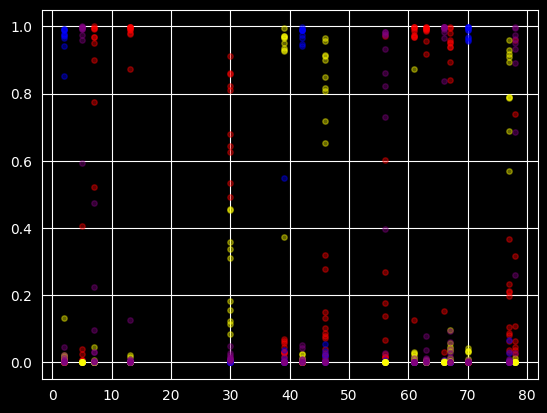

In [99]:
colours = ["r", "b", "yellow", "purple"]

for i in range(preds.shape[2]):
    xs = np.tile(np.array(test_idx)[list(range(N_trials_te))], 10)
    ys = preds[:, :, i].reshape(-1)
    plt.scatter(xs, ys, 15, colours[i], alpha=0.4)

When the model is set to training mode using `model.train()`, it performs the dropout step (as a part of the dropout layer), which is required for the training of the model, however when in evaluation mode (`model.eval()`) this dropout layer is not used. So, the difference between evaluating the predictions when set to training mode and evaluation mode is that in training mode, the dropout layer is still performed (ie. $80\%$ of the entries are zeroed).

<a name="task-2"></a>

# Task 2: Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)